#Employee Attrition Prediction

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Task 1 — Data Loading & Exploration

In [134]:
#Loading the dataset
#Dataset was pushed to GitHub and then copied in url, to avoid manual uploading of any file.
url = "https://raw.githubusercontent.com/puranik1406/XYlofyAI_Internship/refs/heads/main/Week%202/HR_Attrition.csv"
df = pd.read_csv(url)

In [135]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [136]:
df.shape   #To know the number of rows and columns

(1470, 35)

The dataset has 35 columns and 1470 rows/records.

In [137]:
df.describe()   #Gives metrics like count,mean,standard deviation,min,max etc of numerical features of the dataset.

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Attrition- Yes/No is the target column

In [138]:
df["Attrition"].value_counts()      #how many employees left vs stayed

,count
Attrition,
No,1233
Yes,237


In [139]:
#Attrition Rate Calculation
left = df['Attrition'].value_counts()["Yes"]
stayed = df['Attrition'].value_counts()["No"]

attrition_rate = (left / (left + stayed)) * 100
print("Attrition Rate (in %): ",attrition_rate)

Attrition Rate (in %):  16.122448979591837


- Out of 1470 employees, 237 have left, resulting in an attrition rate of 16.12%.
- The Attrition Rate is moderately imbalanced.
- This indicates that the data is imbalanced and this needs to be considered while training the model to avoid bias.

In [140]:
# To get the names of columns which are numerical and those which are categorical
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)
cat_cols = df.select_dtypes(include=['object','boolean','category']).columns
print(cat_cols)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


Categorical Features - 9  
Numerical Features - 26

##Task 2 — Data Cleaning & Preprocessing


In [141]:
df.isnull().sum()   #To know each column has how many missing values

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


No Missing Values in any column

In [142]:
df.duplicated().sum()

np.int64(0)

No Duplicate Values

In [143]:
df["EmployeeNumber"].value_counts()   #To demonstrate what kind of values are posessed by this column

,count
EmployeeNumber,
2068,1
1,1
2,1
4,1
5,1
...,...
23,1
22,1
21,1


EmployeeNumber is basically an ID issued to each employee. It's values are different for all records and it doesn't affect the target at all.

In [144]:
df["Over18"].value_counts()

,count
Over18,
Y,1470


In [145]:
df["StandardHours"].value_counts()

,count
StandardHours,
80,1470


Over18 and StandardHours values are same for all records - "Y" and "80" respectively.

In [146]:
df = df.drop(columns=["EmployeeNumber", "Over18", "StandardHours"])    #Since these features do not affect the target at all

In [147]:
df.columns    #Columns after dropping EmployeeNumber, Over18 and StandardHours

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [148]:
cols=["Attrition","BusinessTravel","Department","EducationField","Gender","JobRole","MaritalStatus","OverTime"]   #Final Categorical Columns

In [149]:
# To know the unique values each column posesses to perform binary and one hot encoding of them
for col in cols:
  print(df[col].value_counts())
  print("---------------------")

Attrition
No     1233
Yes     237
Name: count, dtype: int64
---------------------
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
---------------------
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
---------------------
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
---------------------
Gender
Male      882
Female    588
Name: count, dtype: int64
---------------------
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
-------

Binary Encoding: Attrition, Gender, OverTime - since these have only 2 categories
   
One Hot Encoding: BusinessTravel, Department, EducationField, JobRole, MaritalStatus - since these have more than 2 categories, which are not in any specific hierarchy(ordinal encoding can't be used here).

In [150]:
df_encoded=df.copy()    #Preserving original dataset so that it can be used for EDA
#Binary Encoding
df_encoded['Attrition']=df_encoded['Attrition'].map({'Yes':1, 'No':0})
df_encoded['Gender']=df_encoded['Gender'].map({'Female':1,'Male':0})
df_encoded['OverTime']=df_encoded['OverTime'].map({'Yes':1, 'No':0})

#One Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=["BusinessTravel","Department","EducationField","JobRole","MaritalStatus"],drop_first=True,dtype=int)

In [151]:
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,2,1,94,3,...,0,0,0,0,0,0,1,0,0,1
1,49,0,279,8,1,1,3,0,61,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1373,2,2,1,4,0,92,2,...,0,1,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,4,1,56,3,...,0,0,0,0,0,1,0,0,1,0
4,27,0,591,2,1,1,1,0,40,3,...,0,1,0,0,0,0,0,0,1,0


In [152]:
df_encoded.columns    #Columns after encoding

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research

In [153]:
from sklearn.preprocessing import StandardScaler    #Scaling the values of features using StandardScaler, to avoid domination of few features whose values are more in magnitude
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']
X_scaled=StandardScaler().fit_transform(X)

In [154]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.224745,1.383138,0.379672,-0.057788,...,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.816497,-0.240677,-1.026167,-0.057788,...,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565
2,0.008343,1.414363,-0.887515,-0.891688,0.0,1.169781,-0.816497,1.284725,-1.026167,-0.961486,...,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650
3,-0.429664,1.461466,-0.764121,1.061787,0.0,1.169781,1.224745,-0.486709,0.379672,-0.961486,...,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-0.816497,-1.274014,0.379672,-0.961486,...,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565


##Task 3 — Exploratory Data Analysis — EDA

###1.Attrition rate by Department

In [155]:
for dept in df['Department'].unique():
  print(dept)
  print(df[df['Department']==dept]['Attrition'].value_counts())
  left = df[df['Department']==dept]['Attrition'].value_counts()["Yes"]
  stayed = df[df['Department']==dept]['Attrition'].value_counts()["No"]
  attrition_rate = (left / (left + stayed)) * 100
  print("Attrition Rate (in %): ",attrition_rate)
  print("-------------------------------------")

Sales
Attrition
No     354
Yes     92
Name: count, dtype: int64
Attrition Rate (in %):  20.62780269058296
-------------------------------------
Research & Development
Attrition
No     828
Yes    133
Name: count, dtype: int64
Attrition Rate (in %):  13.839750260145681
-------------------------------------
Human Resources
Attrition
No     51
Yes    12
Name: count, dtype: int64
Attrition Rate (in %):  19.047619047619047
-------------------------------------


<Axes: xlabel='Department', ylabel='count'>

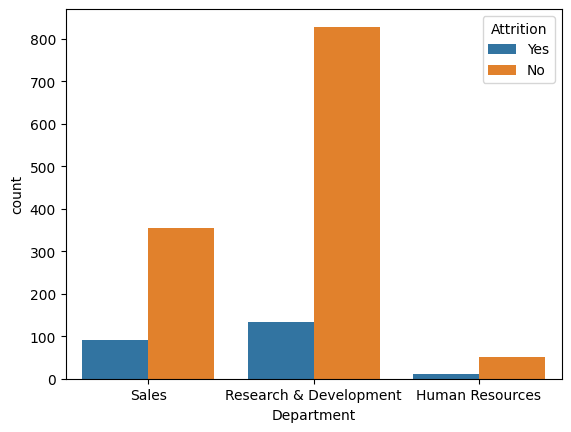

In [156]:
sns.countplot(x='Department',data=df,hue='Attrition')

According to the Attrition Rate calculated, Sales department loses most employees.

###2.Attrition rate by Job Role

In [157]:
for job in df['JobRole'].unique():
  print(job)
  print(df[df['JobRole']==job]['Attrition'].value_counts())
  left = df[df['JobRole']==job]['Attrition'].value_counts()['Yes']
  stayed = df[df['JobRole']==job]['Attrition'].value_counts()['No']
  attrition_rate = (left / (left + stayed)) * 100
  print("Attrition Rate (in %): ",attrition_rate)
  print("-------------------------------------")

Sales Executive
Attrition
No     269
Yes     57
Name: count, dtype: int64
Attrition Rate (in %):  17.484662576687114
-------------------------------------
Research Scientist
Attrition
No     245
Yes     47
Name: count, dtype: int64
Attrition Rate (in %):  16.095890410958905
-------------------------------------
Laboratory Technician
Attrition
No     197
Yes     62
Name: count, dtype: int64
Attrition Rate (in %):  23.93822393822394
-------------------------------------
Manufacturing Director
Attrition
No     135
Yes     10
Name: count, dtype: int64
Attrition Rate (in %):  6.896551724137931
-------------------------------------
Healthcare Representative
Attrition
No     122
Yes      9
Name: count, dtype: int64
Attrition Rate (in %):  6.870229007633588
-------------------------------------
Manager
Attrition
No     97
Yes     5
Name: count, dtype: int64
Attrition Rate (in %):  4.901960784313726
-------------------------------------
Sales Representative
Attrition
No     50
Yes    33
Name: c

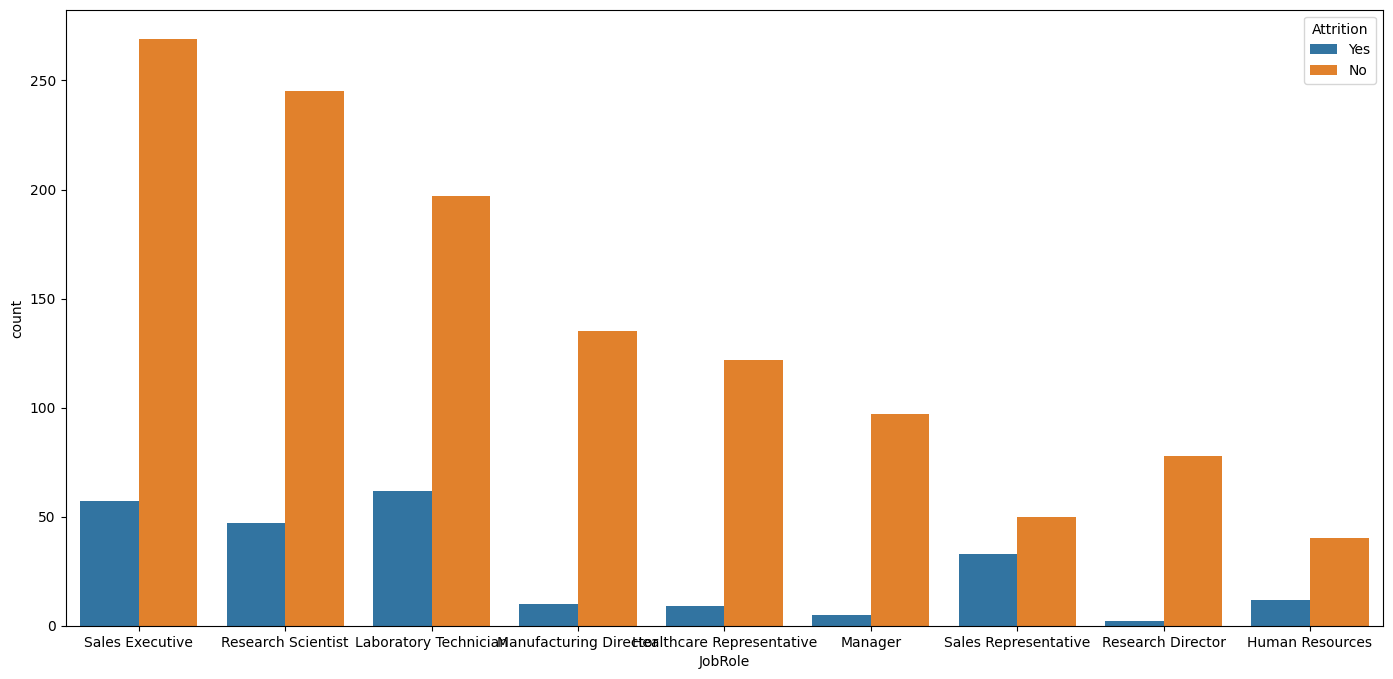

In [158]:
plt.figure(figsize=(17,8))
sns.countplot(x='JobRole',data=df,hue='Attrition')
plt.show()

Sales Representatives have the highest attrition/exit rate of 39.75% followed by Laboratory Technician and Human Representatives respectively.

###3.Attrition vs Monthly Income

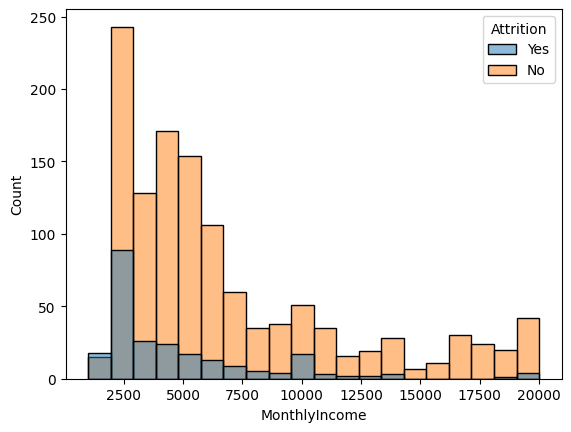

In [159]:
sns.histplot(x='MonthlyIncome',data=df,hue='Attrition')
plt.show()

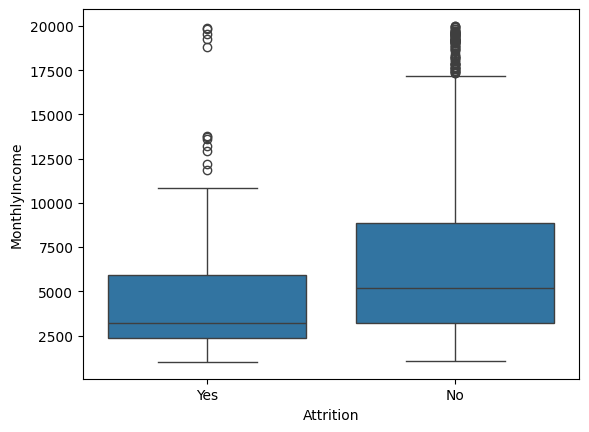

In [160]:
sns.boxplot(x='Attrition',y='MonthlyIncome',data=df)
plt.show()

Employees having low salary ~2500 have the highest count of Attrition, indicating that employees with low salary do tend to leave more.  
It is evident from the histogram and boxplot(Most of the employees who leave fall on the lower side of income, few employees are however present as circles on the higher income side, representing outliers).

###4.Attrition vs Work-Life Balance rating

In [161]:
for wlb in df['WorkLifeBalance'].unique():
  print(wlb)
  print(df[df['WorkLifeBalance']==wlb]['Attrition'].value_counts())
  left = df[df['WorkLifeBalance']==wlb]['Attrition'].value_counts()['Yes']
  stayed = df[df['WorkLifeBalance']==wlb]['Attrition'].value_counts()['No']
  attrition_rate = (left / (left + stayed)) * 100
  print("Attrition Rate (in %): ",attrition_rate)
  print("-------------------------------------")

1
Attrition
No     55
Yes    25
Name: count, dtype: int64
Attrition Rate (in %):  31.25
-------------------------------------
3
Attrition
No     766
Yes    127
Name: count, dtype: int64
Attrition Rate (in %):  14.221724524076148
-------------------------------------
2
Attrition
No     286
Yes     58
Name: count, dtype: int64
Attrition Rate (in %):  16.86046511627907
-------------------------------------
4
Attrition
No     126
Yes     27
Name: count, dtype: int64
Attrition Rate (in %):  17.647058823529413
-------------------------------------


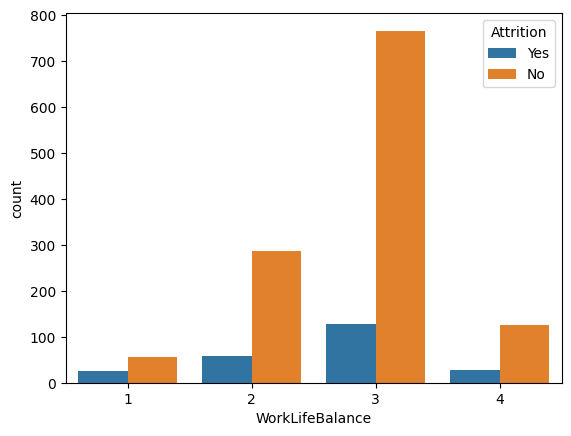

In [162]:
sns.countplot(x='WorkLifeBalance',data=df,hue='Attrition')
plt.show()

Employees having WorkLifeBalance Rating of 1 tend to leave more, compared to the ones who manage to maintain work-life balance well.

###5.Attrition vs Years at Company

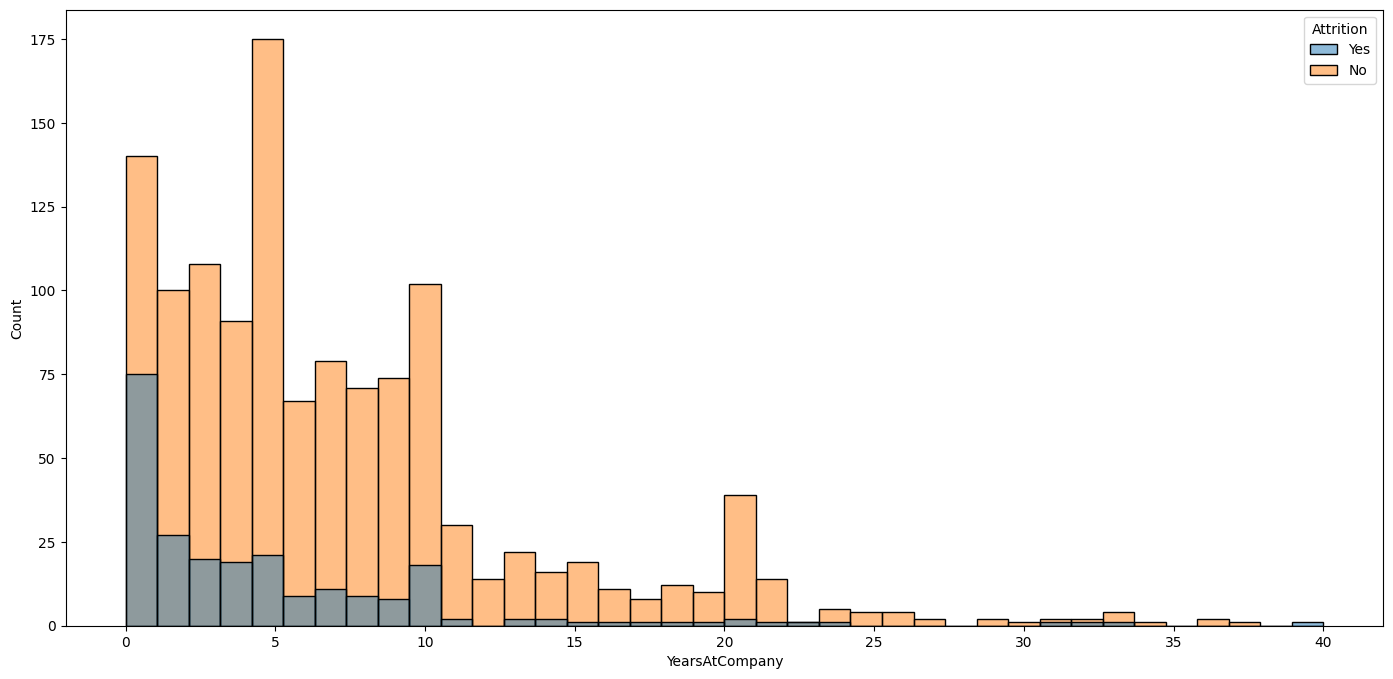

In [163]:
plt.figure(figsize=(17,8))
sns.histplot(x='YearsAtCompany',data=df,hue='Attrition')
plt.show()

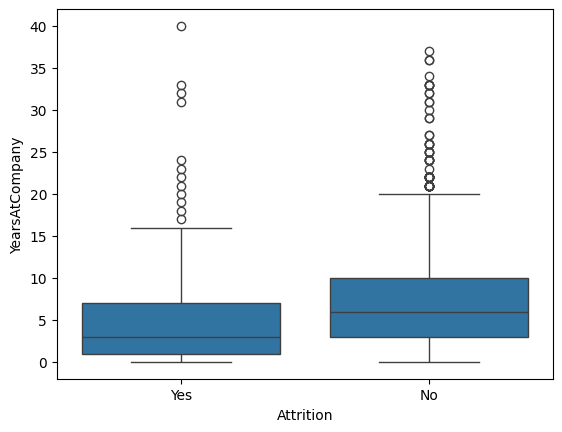

In [164]:
sns.boxplot(x='Attrition',y='YearsAtCompany',data=df)
plt.show()

Most of the employees tend to leave within a year or 2.

##Business Insights
- Sales Department has high attrition rate - 20.62% compared to Research and Development(13.83%) and Human Resources(19.04%).
  - This suggests that company should put more efforts and try to prioritize retention there.

- Within Sales Department, Sales Representatives tend to leave more - 39.75%.

- Employees who left generally have lower monthly incomes. The median income is around 2,500–3,000, and most employees who left earn less than 5,000 per month.

- Employees who have low work-life balance rating of 1, have high exit rate - 31.25% compared to the ones whose rating is 2-4, 3 having the lowest rate.

- Most of the employees who exit, leave within 2 years of tenure, suggesting that company should focus on how to keep new employees engaged.

##Task 4 — Model Building & Comparison

In [165]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)    #80/20 train/test split- 0.2 indicates 20% of the data is used for testing.


###Logistic Regression Model

In [166]:
from sklearn.linear_model import LogisticRegression
lrmodel = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)    #Max Iterations was changed to 1000, 2000 and trained, but showed no change, therefore finally set to 500
lrmodel.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [167]:
y_pred_lr = lrmodel.predict(X_test)   #Test dataset prediction
y_pred_lr_train = lrmodel.predict(X_train)    #Train dataset prediction

###Random Forest Classifier Model

In [168]:
from sklearn.ensemble import RandomForestClassifier
rfmodel=RandomForestClassifier(class_weight='balanced',random_state=42,n_estimators=300,max_depth=5,min_samples_leaf=2)   #Parameters were set to different values and tested, the best values were picked according to the metrics measured
rfmodel.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2,
                       n_estimators=300, random_state=42)

In [169]:
y_pred_rf = rfmodel.predict(X_test)   #Test dataset prediction
y_pred_rf_train = rfmodel.predict(X_train)  #Train dataset prediction

###Gradient Boosting Classifier Model

In [170]:
from sklearn.ensemble import GradientBoostingClassifier
gbmodel = GradientBoostingClassifier(random_state=42,n_estimators=300,max_depth=5,learning_rate=0.1)  #Parameters were set to different values and tested, the best values were picked according to the metrics measured
gbmodel.fit(X_train,y_train)

GradientBoostingClassifier(max_depth=5, n_estimators=300, random_state=42)

In [171]:
y_pred_gb = gbmodel.predict(X_test)   #Test dataset prediction
y_pred_gb_train = gbmodel.predict(X_train)  #Train dataset prediction

Comparision Table of Test & Train Accuracy Scores of all Models

In [172]:
from sklearn.metrics import accuracy_score
#Comaprision Table Data Frame
results = pd.DataFrame({
    "Model":["LogisticRegression","RandomForestClassifier","GradientBosstingClassifier"],
    "Train Accuracy": [accuracy_score(y_train,y_pred_lr_train),accuracy_score(y_train,y_pred_rf_train),accuracy_score(y_train,y_pred_gb_train)],
    "Test Accuracy": [accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_rf),accuracy_score(y_test,y_pred_gb)]
})

In [173]:
results.round(4)

,Model,Train Accuracy,Test Accuracy
0,LogisticRegression,0.7976,0.7177
1,RandomForestClassifier,0.8937,0.8231
2,GradientBosstingClassifier,1.0000,0.8673


##Task 5 — Model Evaluation

Precision, Recall and F1 Score

In [174]:
from sklearn.metrics import precision_score,recall_score,f1_score
#Metrics Data Frame
metrics = pd.DataFrame({
    "Model":["LogisticRegression","RandomForestClassifier","GradientBosstingClassifier"],
    "Precision":[precision_score(y_test,y_pred_lr),precision_score(y_test,y_pred_rf),precision_score(y_test,y_pred_gb)],
    "Recall":[recall_score(y_test,y_pred_lr),recall_score(y_test,y_pred_rf),recall_score(y_test,y_pred_gb)],
    "F1 Score":[f1_score(y_test,y_pred_lr),f1_score(y_test,y_pred_rf),f1_score(y_test,y_pred_gb)]
})

In [175]:
metrics.round(4)

,Model,Precision,Recall,F1 Score
0,LogisticRegression,0.2556,0.5897,0.3566
1,RandomForestClassifier,0.3415,0.3590,0.3500
2,GradientBosstingClassifier,0.5000,0.2308,0.3158


ROC-AUC Score

In [176]:
from sklearn.metrics import roc_auc_score
print(f"Logistic Regression: {roc_auc_score(y_test,lrmodel.predict_proba(X_test)[:, 1]):.4f}")    #Used model.predict_proba(X_test)[:,1] since we want the probabilities of the greater class
print(f"Random Forest Classifier: {roc_auc_score(y_test,rfmodel.predict_proba(X_test)[:, 1]):.4f}")
print(f"Gradient Boosting Classifier: {roc_auc_score(y_test,gbmodel.predict_proba(X_test)[:, 1]):.4f}")

Logistic Regression: 0.7659
Random Forest Classifier: 0.7210
Gradient Boosting Classifier: 0.7708


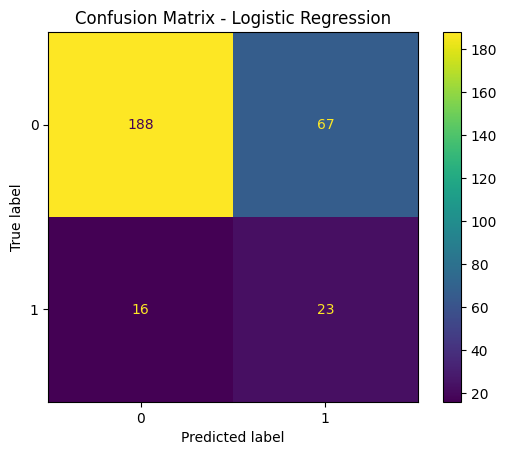

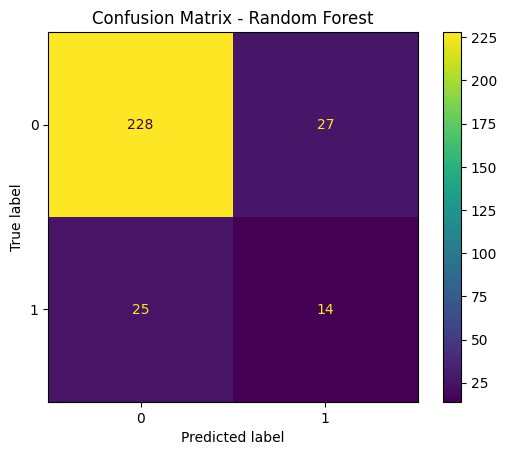

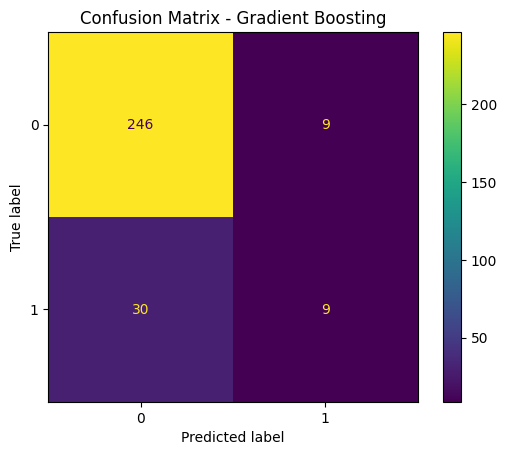

In [177]:
#Confusion Matrix of all 3 models
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lrmodel, X_test, y_test)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
ConfusionMatrixDisplay.from_estimator(rfmodel, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()
ConfusionMatrixDisplay.from_estimator(gbmodel, X_test, y_test)
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

###Best Model?

- Logistic Regression
  - Pros
    - High Recall (58.97%)
    - Good F1 Score (0.3566)
    - Good ROC-AUC Score (0.7659)
  - Cons
    - Lowest Accuracy of all 3 (71.77%)
    - Low Precision (25.56%)
  
>The model can catch and predict employees who are likely to leave correctly, however, it can give many false alarms at the same time. The HR will have to make unnecessary efforts on employees who will stay because of these false positives.

- Random Forest Classifier
  - Pros
    - Good Accuracy (82.31%)
    - Decent Precision, Recall and F1 Score (34.14%, 35.9%, 0.35)
  - Cons
    - Lowest ROC-AUC Score (0.7210)

> The model can catch and predict fewer employees who will leave, but will not give a lot of false positives like Logistic Regression. Unnecessary efforts will be certainly reduced. Although it has low ROC-AUC Score, the difference is not much when compared to the ROC-AUC score of Logistic Regression and Gradient Boosting.

- Gradient Boosting Classifier
  - Pros
    - Best Accuracy (86.73%)
    - Highest Precision (50%)
    - Best ROC-AUC Score (0.7708)
  - Cons
    - Train Accuracy is 100% - sign of overfitting
    - Recall and F1 Score is the lowest (23.08% and 0.3157 respectively)

> The model is very poor at predicting employees who will leave and is likely to give a lot of false negatives. It will give less false positives, saving efforts, however it defeats the main purpose of the prediction.



####Considering the above analysis, ***Random Forest Classifier*** is the best model for the given Employee Attrition Dataset. It helps the HR correctly predict employees who are likely to exit, while saving efforts behind employees who will stay.

Feature Importance - Here are the top 10 features which play an important role in predicting attrition

In [178]:
importance = rfmodel.feature_importances_
# Top Features Data Frame
featurelist = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})
featurelist_sorted = featurelist.sort_values(by="Importance", ascending=False).reset_index(drop=True)
featurelist_sorted.head(10)

,Feature,Importance
0,OverTime,0.124947
1,MonthlyIncome,0.097943
2,StockOptionLevel,0.066031
3,JobLevel,0.059431
4,YearsAtCompany,0.059217
5,Age,0.053989
6,TotalWorkingYears,0.044970
7,YearsWithCurrManager,0.042580
8,MaritalStatus_Single,0.042079
9,YearsInCurrentRole,0.041159


##Task 6 — Visualization

####Chart 1: Bar chart showing attrition rate by Department and Job Role


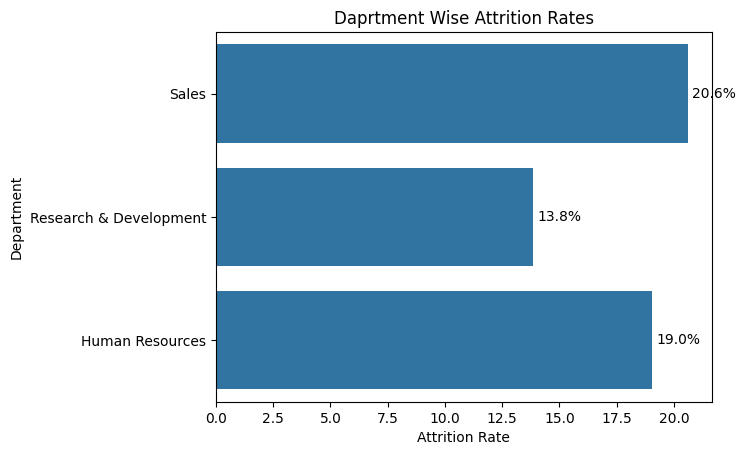

In [179]:
department =[]
attrition_rates = []
for dept in df['Department'].unique():
  department.append(dept)
  left = df[df['Department']==dept]['Attrition'].value_counts()["Yes"]
  stayed = df[df['Department']==dept]['Attrition'].value_counts()["No"]
  attrition_rate = (left / (left + stayed)) * 100
  attrition_rates.append(attrition_rate)

dept_attr = pd.DataFrame({
    "Department": department,
    "Attrition Rate": attrition_rates
})

ax=sns.barplot(x='Attrition Rate',y='Department', data = dept_attr)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.title("Daprtment Wise Attrition Rates")
plt.show()

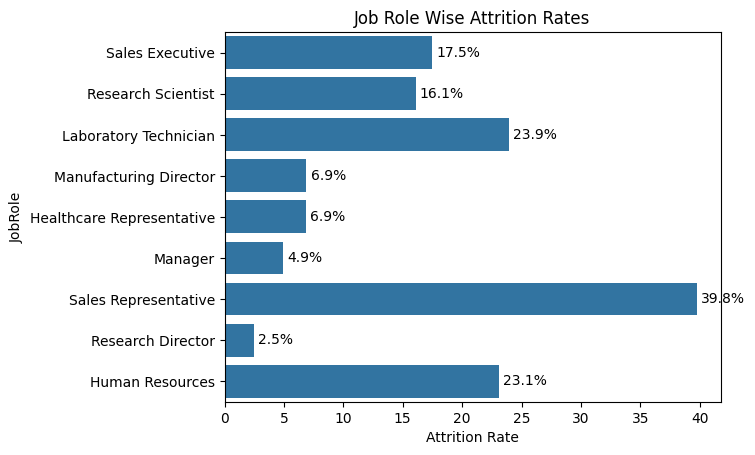

In [180]:
jobrole =[]
attrition_rates = []
for job in df['JobRole'].unique():
  jobrole.append(job)
  left = df[df['JobRole']==job]['Attrition'].value_counts()["Yes"]
  stayed = df[df['JobRole']==job]['Attrition'].value_counts()["No"]
  attrition_rate = (left / (left + stayed)) * 100
  attrition_rates.append(attrition_rate)

jobrole_attr = pd.DataFrame({
    "JobRole": jobrole,
    "Attrition Rate": attrition_rates
})

ax=sns.barplot(x='Attrition Rate',y='JobRole', data = jobrole_attr)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.title("Job Role Wise Attrition Rates")
plt.show()

####Chart 2:  Box plot comparing Monthly Income of employees who left vs stayed

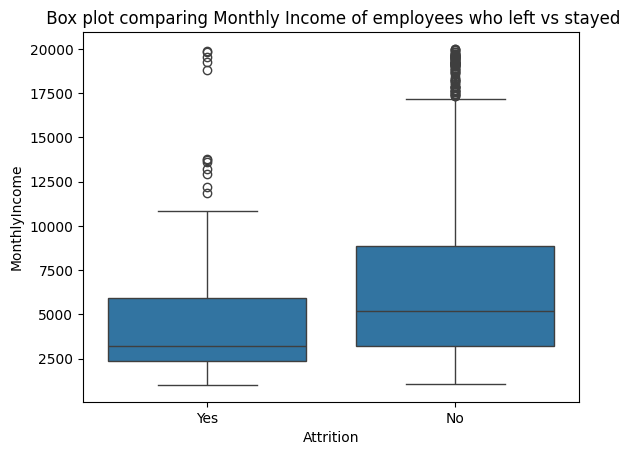

In [181]:
sns.boxplot(x='Attrition',y='MonthlyIncome',data=df)
plt.title(" Box plot comparing Monthly Income of employees who left vs stayed")
plt.show()

####Chart 3: Confusion Matrix heatmap for your best model

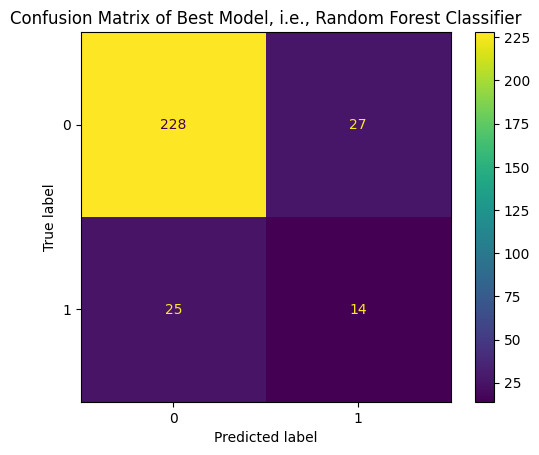

In [182]:
ConfusionMatrixDisplay.from_estimator(rfmodel, X_test, y_test)
plt.title("Confusion Matrix of Best Model, i.e., Random Forest Classifier")
plt.show()

####Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

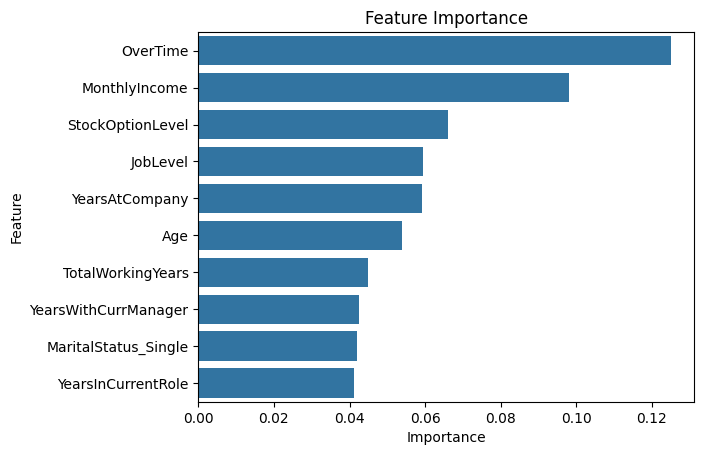

In [183]:
sns.barplot(x='Importance',y='Feature',data=featurelist_sorted.head(10))
plt.title("Feature Importance")
plt.show()

####Chart 5 : ROC Curve comparing all 3 models on one graph

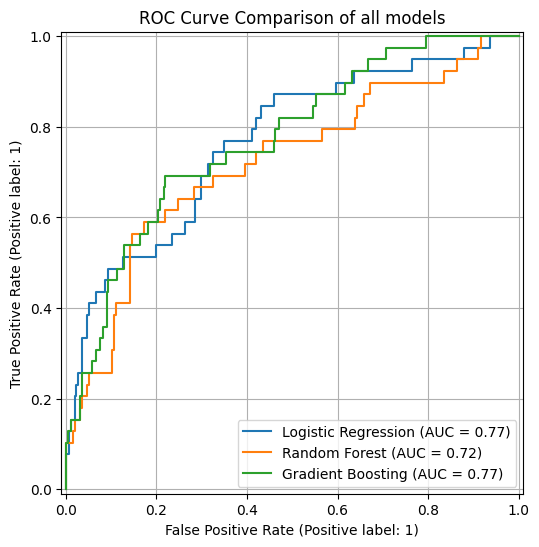

In [184]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8,6))
RocCurveDisplay.from_estimator(lrmodel, X_test, y_test,name="Logistic Regression",ax=ax)        # ax = ax for all 3 to display ROC curves in 1 graph
RocCurveDisplay.from_estimator(rfmodel, X_test, y_test,name="Random Forest",ax=ax)
RocCurveDisplay.from_estimator(gbmodel, X_test, y_test,name="Gradient Boosting",ax=ax)

plt.title("ROC Curve Comparison of all models")
plt.grid(True)
plt.show()

####For better understanding

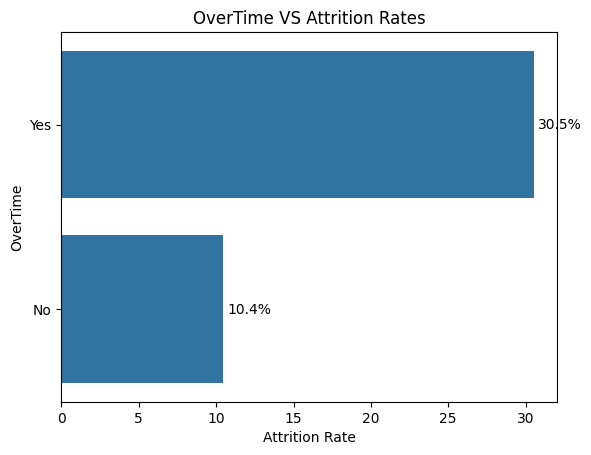

In [185]:
overtime =[]
attrition_rates = []
for ot in df['OverTime'].unique():
  overtime.append(ot)
  left = df[df['OverTime']==ot]['Attrition'].value_counts()["Yes"]
  stayed = df[df['OverTime']==ot]['Attrition'].value_counts()["No"]
  attrition_rate = (left / (left + stayed)) * 100
  attrition_rates.append(attrition_rate)

overtime_attr = pd.DataFrame({
    "OverTime": overtime,
    "Attrition Rate": attrition_rates
})

ax=sns.barplot(x='Attrition Rate',y='OverTime', data = overtime_attr)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.title("OverTime VS Attrition Rates")
plt.show()

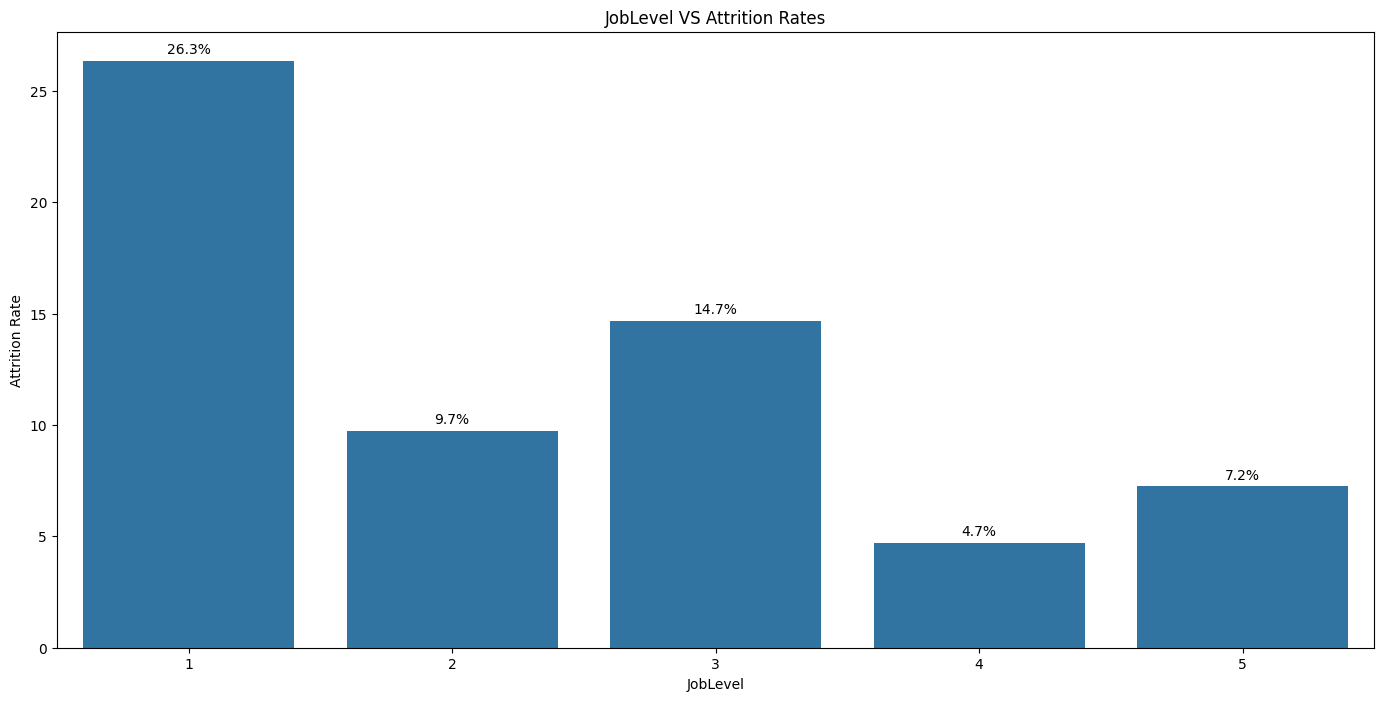

In [186]:
joblevel =[]
attrition_rates = []
for jl in df['JobLevel'].unique():
  joblevel.append(jl)
  left = df[df['JobLevel']==jl]['Attrition'].value_counts()["Yes"]
  stayed = df[df['JobLevel']==jl]['Attrition'].value_counts()["No"]
  attrition_rate = (left / (left + stayed)) * 100
  attrition_rates.append(attrition_rate)

joblevel_attr = pd.DataFrame({
    "JobLevel": joblevel,
    "Attrition Rate": attrition_rates
})

plt.figure(figsize=(17,8))
ax=sns.barplot(x='JobLevel',y='Attrition Rate', data = joblevel_attr)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.title("JobLevel VS Attrition Rates")
plt.show()

##Task 7 — HR Insights & Business Recommendations

1. Which 3 factors most strongly predict that an employee will leave?
> Overtime, MonthlyIncome and StockOptionLevel are the 3 most important factors which strongly predict if an employee will leave.

2. Which department or job role should HR prioritize for retention efforts?
> HR should prioritize Sales Department and specifically the Sales Representative Job Role for retention efforts, since the attrition rate is highest for them, when compared to other departments and job roles.

3. Does salary alone explain attrition or are there other stronger factors?
> MonthlyIncome is an important factor in predicting attrition. However, salary alone does not explain why employees leave. OverTime is an even stronger predictor of attrition. Other factors such as StockOptionLevel, JobRole, and YearsAtCompany also play an important role, although they are less influential than salary.

4. Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation)
> * Policy Changes:
>   * HR should ensure that workloads are distributed more evenly so that employees are not regularly required to work overtime, as excessive overtime is strongly associated with higher attrition.  
>   * HR should review the company's stock option policy and provide better stock option benefits to deserving employees, as this may encourage them to stay longer.
>    * An increment in salaries can be considered for deserving employees whose current salary is on the lower side.
>     * HR should prioritize and focus on ideas on how to engage new employees, introduce incentives, good mentorship, interesting projects etc. since more employees tend to leave within a year/couple of years.
> * Target for Retention Conversation :
>   * Sales Department Employees have a higher exit rate than others, HR should prioritize a retention conversation with them, specifically Sales Representatives as they have the highest exit rate than employees of other job roles.
>   * Retention Converstaions can also be held with new employees to undertand what difficulties they face and get a feedback on policy changes that can be made for them.

5. What limitation does this model have that an HR team should be aware of before using it?
> HR should keep in mind that the model is not perfect. Some employees who are actually at risk of leaving may not be identified (false negatives), while others may be predicted to leave even though they will stay (false positives). Therefore, the model should be used as a decision-support tool alongside human judgment, rather than as the sole basis for decisions.
